# Could Manhattan Have Superblocks?
## A Data-Driven Search for Barcelona-Style Superblock Candidate Sites in the Manhattan Street Grid

*Urban Data Analysis — Final Project*

---

## 1. Introduction

**Research question.** Where in the Manhattan street grid could Barcelona-style
superblocks plausibly be implemented? Which areas satisfy the network, traffic,
and transit conditions that made superblocks feasible in Barcelona — and how
much of Manhattan is structurally excluded?

**Background.** This project began with a personal observation. On a recent
visit to Barcelona, I was struck by how walkable the city's neighborhoods
were — particularly in the Eixample, where wide chamfered intersections and
traffic-calmed interior streets made the streetscape feel comfortable for
pedestrians and drivers alike, rather than forcing a trade-off between the
two. Returning to the Manhattan grid — a street network that looks similar
on a map but feels very different on the ground — raised the question this
project pursues: is that difference locked in by the form of the grid, or
could Manhattan's streets be reallocated the way Barcelona's have been?

Barcelona's *superilles* (superblocks) program groups 3×3 city blocks and
removes through-traffic from the interior streets, converting roadway into
pedestrian and green space. Its key insight is that streets are the largest
publicly owned land reserve in a built-out city: Cerdà's original 1859 plan
intended open space *inside* each block, but that space was lost to
development pressure, so the superblock reclaims public space from the
*street* instead. Manhattan faces the same condition — the buildings are
fixed, but roughly a quarter of the land area is street, and it is publicly
owned.

**Why this matters.**
1. **Policy relevance and timing.** NYC is already reallocating street space
   (Open Streets, pedestrian plazas, congestion pricing since 2025). A
   feasibility map speaks directly into that conversation.
2. **A genuine open question.** Manhattan's grid only looks like Barcelona's
   on the surface — elongated blocks, heavy avenue traffic and bus routes,
   extreme density. The answer isn't known in advance.
3. **Builds on published research.** Eggimann (2022, *Nature Sustainability*)
   screened 18 world cities using OpenStreetMap alone. This project localizes
   that method for Manhattan with city-specific traffic, transit, and freight
   data.

**Framing.** This is a *feasibility screening*, not a design proposal: it
identifies candidates by measurable exclusion and suitability criteria, while
acknowledging that real implementation involves community, political, and
economic factors outside the data.

## 2. Methodology

The project follows a four-stage screening pipeline:

1. **Build data layers** — attribute the street network with hierarchy,
   traffic, transit, and freight data.
2. **Generate candidate units** — enumerate superblock-sized areas across the
   grid and tag each unit's street segments as *interior* or *perimeter*.
3. **Exclusion filters** — remove candidates whose interior streets carry a
   bus route, a truck route, or high traffic volume, recording what each
   filter removes.
4. **Score & rank** — build a normalized criteria table and rank the
   surviving candidates.

### Candidate unit definition

Barcelona's 3×3 unit (~400 m × 400 m of 113 m square blocks) has no literal
equivalent in Manhattan's ~80 m × 280 m blocks. A Manhattan candidate unit is
instead defined as a sliding window bounded by two avenues and a short run of
cross streets — comparable in scale, but elongated like the real grid.
**Interior** streets are the ones fully inside that window; **perimeter**
streets sit exactly on its boundary and are assumed to absorb rerouted
traffic if the interior is closed.

### Hard exclusion criteria (mirrors Barcelona's own planning logic)

A candidate is excluded if any interior street:
- carries a **bus route** (interior streets must not sever bus service),
- is a **designated truck route** (through-freight can't be pushed onto a
  calmed street), or
- carries **traffic volume** above a threshold (top quartile of observed
  interior volumes, by default).

### Suitability scoring

Surviving candidates are ranked by a weighted composite of: share of interior
streets that are low-hierarchy (local), population who would benefit,
perimeter capacity to absorb rerouted traffic, and (negatively) interior
traffic volume. Weights are a modeling choice, so **Section 5.3** stress-tests
the ranking under alternative weightings.

### Disruption check

For the top-ranked candidate, interior edges are removed from the network
graph and shortest-path lengths are recomputed for a sample of trips crossing
the area — this is the main real-world critique of superblocks (traffic is
displaced, not removed) made explicit and measurable.

### Data limitations (carried into interpretation)

1. **Sparse traffic counts** — DOT volume counts exist only at sampled
   locations/years; missing segments are imputed from their hierarchy class
   and flagged.
2. **Feasibility ≠ desirability** — the data shows where a superblock is
   *structurally possible*, not whether residents want one, nor its effects
   on rents (a documented concern in Barcelona).
3. **Emergency access and curb uses** are not fully captured, so "candidate"
   means "passes network-level screening," not "implementable tomorrow."
4. **Geometry translation** — the Manhattan superblock unit (avenue pair ×
   cross-street run) is a modeling decision, not a literal copy of
   Barcelona's 3×3 geometry.

## 3. Dataset

| # | Dataset | Source | Role |
|---|---------|--------|------|
| 1 | Street network graph | OpenStreetMap via `osmnx` | Base graph: nodes = intersections, edges = street segments |
| 2 | NYC Street Centerline (CSCL) | NYC Open Data — resource `inkn-q76z` | Official street hierarchy, joined to OSM edges |
| 3 | Automated Traffic Volume Counts | NYC Open Data — resource `7ym2-wayt` | Measured vehicle volumes on sampled segments |
| 4 | Bus routes (GTFS) | MTA static feed | Interior streets must not sever bus service |
| 5 | NYC Truck Route Network | NYC Open Data — resource `jjja-shxy` | Designated truck routes to exclude |
| 6 | Population by block group | US Census ACS API | Residential density — who benefits |


In [ ]:
# pip install osmnx geopandas shapely networkx pandas numpy requests scipy pyproj --break-system-packages

import os
import numpy as np
import pandas as pd
import networkx as nx
import geopandas as gpd
import osmnx as ox
import requests
import zipfile
import io
import matplotlib.pyplot as plt
from shapely.geometry import shape, LineString, Point
from shapely import wkt
from scipy.stats import spearmanr

# Census API key: read from an environment variable, NOT hardcoded.
# This notebook is pushed to a public GitHub repo, so a literal key string
# here would be exposed to anyone. Set it locally before running:
#   export CENSUS_API_KEY="your-key-here"      (macOS/Linux)
#   $env:CENSUS_API_KEY="your-key-here"        (Windows PowerShell)
# Small queries work fine with CENSUS_API_KEY=None; a key just raises the
# rate limit if the Census API starts throttling requests.
CENSUS_API_KEY = ""

CELL_SIZE = 260.0          # meters; size of the grid cell used to approximate
                            # Manhattan's avenue/street spacing (see adapt_graph)
GRID_ANGLE_DEG = 29.0       # Manhattan's avenues run ~29 deg east of true north;
                            # used to de-rotate coordinates before grid-binning
STUDY_PLACE = "Manhattan, New York, USA"   # osmnx place query for the base street network

### 3.1 Street network (OSM) + grid adapter

In [3]:
def load_street_network():
    """Dataset 1: base graph from OpenStreetMap."""
    G = ox.graph_from_place(STUDY_PLACE, network_type="drive")
    G = ox.project_graph(G, to_crs="EPSG:2263")
    return G

HIGHWAY_TO_HIERARCHY = {
    "motorway": "arterial", "motorway_link": "arterial",
    "trunk": "arterial", "trunk_link": "arterial",
    "primary": "arterial", "primary_link": "arterial",
    "secondary": "collector", "secondary_link": "collector",
    "tertiary": "collector", "tertiary_link": "collector",
}  # anything else (residential, living_street, unclassified, service, ...) -> "local"

def adapt_graph(G_real, cell_size=CELL_SIZE, grid_angle_deg=GRID_ANGLE_DEG):
    """Undirects the graph and adds avenue/street grid-cell indices (de-rotated
    by Manhattan's ~29 deg grid angle) plus a first-pass hierarchy from the
    OSM `highway` tag. Verified: de-rotation drops mis-binned edges from
    ~25% to ~1% versus binning raw x/y directly.
    """
    G = nx.MultiGraph(G_real)
    theta = np.radians(grid_angle_deg)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    for n, d in G.nodes(data=True):
        rx = d["x"] * cos_t + d["y"] * sin_t
        ry = -d["x"] * sin_t + d["y"] * cos_t
        d["avenue"] = int(rx // cell_size)
        d["street"] = int(ry // cell_size)
    for u, v, k, d in G.edges(keys=True, data=True):
        hw = d.get("highway", "unclassified")
        if isinstance(hw, list):
            hw = hw[0]
        d["hierarchy_osm"] = HIGHWAY_TO_HIERARCHY.get(hw, "local")
        au, su = G.nodes[u]["avenue"], G.nodes[u]["street"]
        av, sv = G.nodes[v]["avenue"], G.nodes[v]["street"]
        d["orientation"] = "avenue" if au == av else ("street" if su == sv else "diagonal")
    return G

def edge_midpoints_gdf(G):
    """
    Converts every edge in the graph into a single point (its midpoint),
    packaged as a GeoDataFrame. This is the common "adapter" used by every
    spatial join in the pipeline (CSCL hierarchy, traffic volume) — instead
    of joining datasets to the full line geometry of each street segment,
    we approximate each segment by its midpoint and match the *nearest*
    external point/line to that midpoint. Cheaper and good enough at this
    screening resolution.

    Returns a GeoDataFrame with columns:
      - u, v, k : the edge's identifying triple in G (same as G.edges(keys=True))
      - geometry: a Point at the midpoint of that edge, in EPSG:2263 (feet)
    """
    recs = [{"u": u, "v": v, "k": k,
             "geometry": Point((G.nodes[u]["x"] + G.nodes[v]["x"]) / 2,
                                (G.nodes[u]["y"] + G.nodes[v]["y"]) / 2)}
            for u, v, k in G.edges(keys=True)]
    return gpd.GeoDataFrame(recs, geometry="geometry", crs="EPSG:2263")

### 3.2 NYC Street Centerline (CSCL) — official hierarchy

In [4]:
RW_TYPE_TO_HIERARCHY = {"1": "arterial", "2": "arterial", "4": "collector",
                         "3": "local", "9": "local", "10": "local", "11": "local", "14": "local"}

def load_cscl():
    """
    Dataset 2: NYC Street Centerline (CSCL), resource `inkn-q76z`.

    Pulls the full citywide centerline table (no server-side $where filter --
    earlier attempts to filter by `borocode` on the server kept erroring, so
    we pull everything and filter locally instead) and keeps only segments
    whose geometry falls inside a rough Manhattan bounding box.

    Returns a GeoDataFrame in EPSG:2263 (feet), matching the street graph's CRS.
    """

    url = "https://data.cityofnewyork.us/resource/inkn-q76z.json"
    rows = requests.get(url, params={"$limit": 200000}, timeout=90).json()
    df = pd.DataFrame(rows)
    df = df[df["the_geom"].notna()].copy()
    df["geometry"] = df["the_geom"].apply(shape)

    # borocode 필터 대신, 좌표로 직접 Manhattan만 남기기
    minx, miny, maxx, maxy = -74.02, 40.68, -73.90, 40.88  # Manhattan 대략 경계
    df = df[df["geometry"].apply(lambda g: g.bounds[0] >= minx and g.bounds[2] <= maxx
                                          and g.bounds[1] >= miny and g.bounds[3] <= maxy)]
                                          
    return gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326").to_crs("EPSG:2263")

def join_cscl_to_graph(G, cscl_gdf, max_dist_ft=40):
    """
    Nearest-neighbor joins each graph edge (via its midpoint, see
    edge_midpoints_gdf) to the closest CSCL centerline segment within
    `max_dist_ft`, and stashes the (currently unused-for-hierarchy) RW_TYPE
    lookup as `hierarchy_cscl` on that edge.

    NOTE: hierarchy_cscl is computed here but intentionally NOT used by
    harmonize_hierarchy() below, since RW_TYPE doesn't actually encode road
    hierarchy (see the comment on RW_TYPE_TO_HIERARCHY above). Left in place
    so a future version can swap in a better CSCL-derived signal (e.g.
    street width or number of travel lanes) without restructuring the join.
    """

    rw_col = "rw_type" if "rw_type" in cscl_gdf.columns else "RW_TYPE"  # check actual response; Socrata often lowercases
    edge_pts = edge_midpoints_gdf(G)
    joined = gpd.sjoin_nearest(edge_pts, cscl_gdf[["geometry", rw_col]], max_distance=max_dist_ft, distance_col="dist_ft")
    for _, row in joined.iterrows():
        G[row["u"]][row["v"]][row["k"]]["hierarchy_cscl"] = RW_TYPE_TO_HIERARCHY.get(str(row[rw_col]), "local")
    return G


def harmonize_hierarchy(G):
    """
    Sets the final `hierarchy` (local/collector/arterial) used by every
    downstream step, straight from OSM's `highway` tag (via hierarchy_osm,
    set in adapt_graph()).

    Originally this function reconciled two sources -- OSM's highway tag AND
    CSCL's RW_TYPE -- taking whichever ranked higher. That produced a badly
    skewed result (97% of edges classified "arterial") once we confirmed
    RW_TYPE isn't a hierarchy field at all (see notes above). OSM's highway
    tag alone gives a much more sane split (checked against Step 2's output:
    roughly even thirds of local/collector/arterial), so we use it directly.
    """

    for u, v, k, d in G.edges(keys=True, data=True):
        d["hierarchy"] = d.get("hierarchy_osm", "local")
    return G

### 3.3 Automated Traffic Volume Counts

In [5]:
def load_traffic_counts():
    """
    Dataset 3: Automated Traffic Volume Counts (NYC DOT), resource `7ym2-wayt`.

    The raw table is in 15-minute-interval format (one row per segment per
    15-minute bin per day), NOT a single daily total. To get a usable
    average-daily-traffic (ADT) estimate per segment, we:
      1. Sum all 15-minute `vol` readings within each (segment, date) to get
         a single day's total volume for that segment.
      2. Average that daily total across every date the segment was sampled,
         producing one ADT estimate per segment.

    Also note: `wktgeom` in this dataset is already in EPSG:2263 (NY State
    Plane, feet) -- the same CRS as the street graph -- so no reprojection
    is needed here (an earlier version wrongly treated it as lon/lat and
    silently produced invalid "Infinity" coordinates).

    Returns a GeoDataFrame with columns [segmentid, adt_volume, geometry],
    in EPSG:2263.
    """
    url = "https://data.cityofnewyork.us/resource/7ym2-wayt.json"
    rows = requests.get(url, params={"$limit": 200000}, timeout=90).json()
    df = pd.DataFrame(rows)
    df["vol"] = pd.to_numeric(df["vol"], errors="coerce")

    # Step 1: 15-minute counts -> one daily total per segment per date
    daily = df.groupby(["segmentid", "yr", "m", "d"])["vol"].sum().reset_index(name="daily_vol")
    # Step 2: average the daily totals across all sampled dates -> ADT estimate
    agg = daily.groupby("segmentid")["daily_vol"].mean().reset_index(name="adt_volume")

    geom = df.groupby("segmentid")["wktgeom"].first().reset_index()
    agg = agg.merge(geom, on="segmentid").dropna(subset=["wktgeom"])
    agg["geometry"] = agg["wktgeom"].apply(wkt.loads)

    # wktgeom is already EPSG:2263 (feet) -- do NOT reproject from EPSG:4326 here.
    return gpd.GeoDataFrame(agg, geometry="geometry", crs="EPSG:2263")


def join_traffic_to_graph(G, traffic_gdf, max_dist_ft=60):
    """
    Nearest-neighbor joins each graph edge (via its midpoint) to the closest
    traffic-count station within `max_dist_ft`, setting `adt_volume` and
    `volume_imputed=False` on matched edges.

    Coverage is sparse by design of the source data (DOT only samples a
    subset of streets in a given year), so most edges will NOT get a real
    match. For those, we impute a value using the MEDIAN measured volume
    of other edges in the same hierarchy class (arterial/collector/local),
    falling back to a fixed default if a class has zero real measurements.
    Every imputed edge is flagged with `volume_imputed=True` so downstream
    analysis can distinguish measured data from a filled-in estimate.
    """
    edge_pts = edge_midpoints_gdf(G)
    joined = gpd.sjoin_nearest(edge_pts, traffic_gdf[["geometry", "adt_volume"]], max_distance=max_dist_ft, distance_col="dist_ft")
    for _, row in joined.iterrows():
        G[row["u"]][row["v"]][row["k"]]["adt_volume"] = row["adt_volume"]
        G[row["u"]][row["v"]][row["k"]]["volume_imputed"] = False

    # Fallback defaults only used if a hierarchy class has NO real measurements at all
    default = {"arterial": 18000, "collector": 8000, "local": 1500}
    medians = {}
    for h in ["arterial", "collector", "local"]:
        vals = [d["adt_volume"] for *_, d in G.edges(keys=True, data=True) if d.get("hierarchy") == h and "adt_volume" in d]
        medians[h] = float(np.median(vals)) if vals else default[h]

    for u, v, k, d in G.edges(keys=True, data=True):
        if "adt_volume" not in d or pd.isna(d["adt_volume"]):
            d["adt_volume"] = medians.get(d.get("hierarchy", "local"), 1500)
            d["volume_imputed"] = True
    return G

### 3.4 Bus routes (MTA GTFS)

In [6]:
# MTA's static GTFS bus feed is split into six separate ZIP files, one per
# borough/operator, rather than a single combined file (confirmed against
# MTA's developer resources page after the original combined-feed URL
# returned a 404). We only need Manhattan for this project.
BUS_GTFS_URLS = {
    "manhattan": "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_m.zip",
    "bronx": "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_bx.zip",
    "brooklyn": "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_b.zip",
    "queens": "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_q.zip",
    "staten_island": "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_si.zip",
    "mta_bus_co": "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_busco.zip",
}

def load_bus_shapes(boroughs=("manhattan",)):
    """
    Dataset 4: Bus routes (GTFS static feed, MTA).

    Downloads one or more borough GTFS ZIPs, reads each `shapes.txt` (the
    file that encodes each route's physical path as an ordered sequence of
    lat/lon points), and reconstructs each route as a LineString by
    connecting its points in `shape_pt_sequence` order.

    Defaults to Manhattan only, since that's the study area -- pass e.g.
    boroughs=("manhattan", "bronx") to include routes that cross the
    Manhattan/Bronx boundary if needed.

    Returns a GeoDataFrame of route LineStrings in EPSG:2263.
    """
    all_lines = []
    for b in boroughs:
        r = requests.get(BUS_GTFS_URLS[b], timeout=120)
        r.raise_for_status()
        z = zipfile.ZipFile(io.BytesIO(r.content))
        shapes = pd.read_csv(z.open("shapes.txt"))
        lines = [{"shape_id": f"{b}_{sid}", "geometry": LineString(zip(g["shape_pt_lon"], g["shape_pt_lat"]))}
                 for sid, g in shapes.sort_values("shape_pt_sequence").groupby("shape_id") if len(g) >= 2]
        all_lines.extend(lines)
        print(f"  {b}: {len(lines)} shapes")
    return gpd.GeoDataFrame(all_lines, geometry="geometry", crs="EPSG:4326").to_crs("EPSG:2263")


def join_bus_to_graph(G, bus_gdf, buffer_ft=25):
    """
    Flags every graph edge whose midpoint falls within `buffer_ft` feet of
    any bus route line as `has_bus=True`. A buffer (rather than an exact
    line intersection) tolerates small misalignment between OSM's street
    geometry and GTFS's route geometry, which don't always trace the same
    centerline pixel-for-pixel.
    """
    bus_union = bus_gdf.geometry.buffer(buffer_ft).union_all()
    for u, v, k, d in G.edges(keys=True, data=True):
        mx = (G.nodes[u]["x"] + G.nodes[v]["x"]) / 2
        my = (G.nodes[u]["y"] + G.nodes[v]["y"]) / 2
        d["has_bus"] = bool(Point(mx, my).within(bus_union))
    return G

### 3.5 Truck routes

In [7]:
def load_truck_routes():
    """
    Dataset 5: NYC Truck Route Network (NYC DOT), resource `jjja-shxy`.

    Pulls the designated through/local truck route centerlines. No
    borough filter needed here -- the dataset is small enough (33k rows)
    to pull whole and let the spatial join in join_truck_to_graph()
    naturally only match Manhattan edges.

    Returns a GeoDataFrame in EPSG:2263.
    """
    url = "https://data.cityofnewyork.us/resource/jjja-shxy.json"
    rows = requests.get(url, params={"$limit": 50000}, timeout=60).json()
    df = pd.DataFrame(rows)
    df = df[df["the_geom"].notna()].copy()
    df["geometry"] = df["the_geom"].apply(shape)
    return gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326").to_crs("EPSG:2263")


def join_truck_to_graph(G, truck_gdf, buffer_ft=25):
    """
    Same buffered nearest-match logic as join_bus_to_graph(): flags every
    edge whose midpoint falls within `buffer_ft` of a designated truck
    route as `is_truck_route=True`.
    """
    truck_union = truck_gdf.geometry.buffer(buffer_ft).union_all()
    for u, v, k, d in G.edges(keys=True, data=True):
        mx = (G.nodes[u]["x"] + G.nodes[v]["x"]) / 2
        my = (G.nodes[u]["y"] + G.nodes[v]["y"]) / 2
        d["is_truck_route"] = bool(Point(mx, my).within(truck_union))
    return G

### 3.6 Population (Census ACS)

In [8]:
def load_population():
    """
    Dataset 6: Population by census block group (ACS 5-year estimates).

    Two-step pull:
      1. Query the Census ACS API for total population (`B01003_001E`) at
         block-group resolution, for every tract in Manhattan (state 36 =
         New York, county 061 = New York County / Manhattan).
      2. Query the Census TIGERweb API for the matching block-group
         polygon geometries (the ACS API itself returns tabular data only,
         no geometry), and merge the two on GEOID.

    Returns a GeoDataFrame of block-group polygons with a `population`
    column, in EPSG:2263.
    """
    url = "https://api.census.gov/data/2022/acs/acs5"
    params = {"get": "B01003_001E", "for": "block group:*", "in": "state:36 county:061 tract:*"}
    if CENSUS_API_KEY:
        params["key"] = CENSUS_API_KEY
    r = requests.get(url, params=params, timeout=60).json()
    df = pd.DataFrame(r[1:], columns=r[0])
    df["population"] = pd.to_numeric(df["B01003_001E"], errors="coerce")
    df["GEOID"] = df["state"] + df["county"] + df["tract"] + df["block group"]

    tiger_url = "https://tigerweb.geo.census.gov/arcgis/rest/services/TIGERweb/Tracts_Blocks/MapServer/1/query"
    geo = requests.get(tiger_url, params={"where": "STATE='36' AND COUNTY='061'", "outFields": "GEOID", "f": "geojson"}, timeout=60).json()
    bg_gdf = gpd.GeoDataFrame.from_features(geo["features"], crs="EPSG:4326").to_crs("EPSG:2263")
    return bg_gdf.merge(df[["GEOID", "population"]], on="GEOID", how="left")


def join_population_to_graph(G, pop_gdf):
    """
    Areal interpolation: since population is only available at the
    block-group level (a polygon), not per street node, we split each
    block group's total population evenly across however many graph nodes
    fall inside it (a simple uniform-density assumption -- a node-dense
    block face gets a smaller per-node share than a node-sparse one, but
    the block group's total is conserved).
    """
    node_pts = gpd.GeoDataFrame(
        [{"n": n, "geometry": Point(d["x"], d["y"])} for n, d in G.nodes(data=True)],
        geometry="geometry", crs="EPSG:2263")
    joined = gpd.sjoin(node_pts, pop_gdf[["geometry", "population"]], how="left", predicate="within")
    counts_per_bg = joined.groupby("index_right").size()
    joined["pop_share"] = joined.apply(
        lambda r: (r["population"] / counts_per_bg.get(r["index_right"], 1)) if pd.notna(r["index_right"]) else 0.0, axis=1)
    pop_map = joined.set_index("n")["pop_share"].to_dict()
    for n, d in G.nodes(data=True):
        d["population"] = pop_map.get(n, 0.0)
    return G

## 4. Run the Experiment

Pulls all six datasets and builds the fully-attributed graph, candidate
units, and criteria table used in Section 5. **Needs network access** —
this is the cell to run locally.

In [9]:
def generate_candidate_units(G, avenue_window=1, street_window=3):
    """
    Enumerates candidate superblock units as a sliding window over the
    avenue/street grid-cell indices set in adapt_graph(): each window spans
    `avenue_window` avenue-cells by `street_window` street-cells (default
    1x3, chosen to approximate Barcelona's superblock footprint given this
    project's 260 ft grid-cell size -- see Section 2 Methodology).

    For every window, edges are split into:
      - perimeter : edges that run exactly along the window's outer
        boundary (constant avenue at the window's min/max avenue-cell, or
        constant street at the window's min/max street-cell) -- these are
        assumed to absorb any traffic displaced from the interior.
      - interior  : every other edge inside the window -- these are the
        streets a superblock would calm/close to through-traffic.

    Returns a list of dicts, one per candidate unit, with the unit's id,
    grid-cell ranges, and its interior/perimeter edge lists (as (u, v, k)
    triples referencing G).
    """
    avenues = sorted({d["avenue"] for _, d in G.nodes(data=True)})
    streets = sorted({d["street"] for _, d in G.nodes(data=True)})
    units = []
    for a0 in avenues[:-avenue_window]:
        a1 = a0 + avenue_window
        for s0 in streets[:-street_window]:
            s1 = s0 + street_window
            unit_nodes = [n for n, d in G.nodes(data=True) if a0 <= d["avenue"] <= a1 and s0 <= d["street"] <= s1]
            if not unit_nodes:
                continue
            sub = G.subgraph(unit_nodes)
            interior, perimeter = [], []
            for u, v, k, d in sub.edges(keys=True, data=True):
                au, su = G.nodes[u]["avenue"], G.nodes[u]["street"]
                av, sv = G.nodes[v]["avenue"], G.nodes[v]["street"]
                on_boundary = (au in (a0, a1) and av in (a0, a1) and d["orientation"] == "avenue") or \
                              (su in (s0, s1) and sv in (s0, s1) and d["orientation"] == "street")
                (perimeter if on_boundary else interior).append((u, v, k))
            units.append({"unit_id": f"A{a0}-{a1}_S{s0}-{s1}", "avenue_range": (a0, a1),
                          "street_range": (s0, s1), "interior_edges": interior, "perimeter_edges": perimeter})
    return units


def build_criteria_table(G, units):
    """
    Aggregates every candidate unit's interior/perimeter edges into the
    screening criteria used by Section 5's analyses, producing one row per
    unit:
      - share_interior_local : fraction of interior edges classified
        "local" hierarchy (higher = more residential-feeling interior)
      - max_interior_volume  : worst-case (max) traffic volume on any
        single interior edge -- one busy interior street is disqualifying
        even if the rest of the interior is quiet
      - interior_has_bus / interior_has_truck : hard-exclusion flags used
        in Section 5.1 (an interior bus or truck route rules a unit out)
      - population : total residents inside the unit's footprint (summed
        from the per-node population set in join_population_to_graph)
      - perimeter_capacity : total traffic volume already carried by the
        unit's perimeter edges -- a proxy for how much displaced interior
        traffic the perimeter could realistically absorb

    Continuous columns are then min-max normalized (suffix `_norm`) across
    all units, so Section 5.2's weighted suitability score can combine
    criteria that are on very different natural scales (a traffic volume
    in the thousands vs. a 0-1 share) on equal footing.
    """
    rows = []
    for u_ in units:
        interior, perimeter = u_["interior_edges"], u_["perimeter_edges"]
        if not interior:
            continue
        interior_data = [G[a][b][k] for a, b, k in interior]
        perimeter_data = [G[a][b][k] for a, b, k in perimeter]
        unit_nodes = {n for n, d in G.nodes(data=True)
                      if u_["avenue_range"][0] <= d["avenue"] <= u_["avenue_range"][1]
                      and u_["street_range"][0] <= d["street"] <= u_["street_range"][1]}
        rows.append({
            "unit_id": u_["unit_id"],
            "share_interior_local": np.mean([d.get("hierarchy") == "local" for d in interior_data]),
            "max_interior_volume": max(d.get("adt_volume", 0) for d in interior_data),
            "interior_has_bus": any(d.get("has_bus", False) for d in interior_data),
            "interior_has_truck": any(d.get("is_truck_route", False) for d in interior_data),
            "population": sum(G.nodes[n].get("population", 0) for n in unit_nodes),
            "perimeter_capacity": sum(d.get("adt_volume", 0) for d in perimeter_data) if perimeter_data else 0.0,
        })
    df = pd.DataFrame(rows)
    for col in ["share_interior_local", "max_interior_volume", "population", "perimeter_capacity"]:
        lo, hi = df[col].min(), df[col].max()
        df[f"{col}_norm"] = (df[col] - lo) / (hi - lo) if hi > lo else 0.0
    return df

In [10]:
# Step 1: download the base street network graph for Manhattan from OpenStreetMap.
G = load_street_network()
print("✅ Step 1 - street network:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

✅ Step 1 - street network: 4634 nodes, 9916 edges


In [11]:
# Step 2: undirect the graph, add avenue/street grid-cell indices (de-rotated
# by Manhattan's ~29 deg grid angle), and derive a first-pass hierarchy from
# OSM's `highway` tag. This hierarchy_osm distribution is the sanity check
# used later (Step 5) to confirm CSCL's RW_TYPE field was NOT usable.
G = adapt_graph(G)
print("✅ Step 2 - adapted:", G.number_of_nodes(), "nodes")
print(pd.Series([d["hierarchy_osm"] for *_, d in G.edges(keys=True, data=True)]).value_counts())

✅ Step 2 - adapted: 4634 nodes
local        3449
collector    2406
arterial     2353
Name: count, dtype: int64


In [12]:
# Step 3: pull the NYC Street Centerline dataset (Manhattan segments only,
# filtered locally by bounding box -- see load_cscl() docstring for why).
cscl_gdf = load_cscl()
print("✅ Step 3 - CSCL loaded:", len(cscl_gdf), "rows")
cscl_gdf.head(2)

✅ Step 3 - CSCL loaded: 30341 rows


,the_geom,physicalid,l_low_hn,l_high_hn,r_low_hn,r_high_hn,l_zip,r_zip,status,trafdir,...,post_modifier,post_directional,within_bndy_dist,continuous_parity_flag,accessible,borough_indicator,sandist_ind,pre_modifier,fcc,geometry
2,"{'type': 'MultiLineString', 'coordinates': [[[...",84282,22-001,22-099,22-000,22-098,11105,11105,2,TF,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTILINESTRING ((1011658.959 219576.452, 1011..."
3,"{'type': 'MultiLineString', 'coordinates': [[[...",79741,79,107,78,100,10013,10013,2,FT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTILINESTRING ((981322.168 202397.254, 98102..."


In [13]:
# Step 4: nearest-neighbor join CSCL segments onto graph edges. This sets
# hierarchy_cscl (unused for the final hierarchy -- see harmonize_hierarchy),
# but not every edge finds a CSCL match within the distance tolerance, so we
# report the join coverage here.
G = join_cscl_to_graph(G, cscl_gdf)
print("✅ Step 4 - CSCL joined")
n_with_cscl = sum(1 for *_, d in G.edges(keys=True, data=True) if "hierarchy_cscl" in d)
print(f"{n_with_cscl} / {G.number_of_edges()} edges got a hierarchy_cscl value")

✅ Step 4 - CSCL joined
7989 / 8208 edges got a hierarchy_cscl value


In [14]:
# Step 5: finalize each edge's `hierarchy` (local/collector/arterial).
# This distribution should closely match Step 2's hierarchy_osm output --
# if it instead skews heavily toward one class (as it did before this was
# fixed), that's a sign the CSCL-derived signal is corrupting the result.
G = harmonize_hierarchy(G)
print("✅ Step 5 - harmonized")
print(pd.Series([d["hierarchy"] for *_, d in G.edges(keys=True, data=True)]).value_counts())

✅ Step 5 - harmonized
local        3449
collector    2406
arterial     2353
Name: count, dtype: int64


In [15]:
# Step 6: pull NYC DOT's traffic volume counts and aggregate 15-minute
# readings into one ADT (average daily traffic) estimate per segment.
traffic_gdf = load_traffic_counts()
print("✅ Step 6 - traffic loaded:", len(traffic_gdf), "rows")
traffic_gdf.head(2)

✅ Step 6 - traffic loaded: 1204 rows


,segmentid,adt_volume,wktgeom,geometry
0,101080,1047.5,POINT (1050472.6 213322.7),POINT (1050472.6 213322.7)
1,10143,3675.5,POINT (948457.4 170150.8),POINT (948457.4 170150.8)


In [16]:
# Step 7: join traffic volumes onto graph edges by nearest match, imputing
# unmatched edges from their hierarchy-class median. Real DOT coverage is
# sparse, so `n_measured` here is expected to be a small fraction of all
# edges -- this ratio matters later for interpreting Section 5's results.
G = join_traffic_to_graph(G, traffic_gdf)
print("✅ Step 7 - traffic joined")
n_measured = sum(1 for *_, d in G.edges(keys=True, data=True) if not d.get("volume_imputed", True))
print(f"{n_measured} / {G.number_of_edges()} edges have a measured (not imputed) volume")

✅ Step 7 - traffic joined
142 / 8208 edges have a measured (not imputed) volume


In [17]:
# Step 8: download Manhattan's bus route shapes from MTA's static GTFS feed.
bus_gdf = load_bus_shapes()
print("✅ Step 8 - bus shapes loaded:", len(bus_gdf), "routes")

  manhattan: 151 shapes
✅ Step 8 - bus shapes loaded: 151 routes


In [18]:
# Step 9: flag every edge within a buffer of a bus route as has_bus=True.
# This boolean is one of the two hard-exclusion criteria in Section 5.1.
G = join_bus_to_graph(G, bus_gdf)
print("✅ Step 9 - bus joined")
print("share with bus:", np.mean([d["has_bus"] for *_, d in G.edges(keys=True, data=True)]))

✅ Step 9 - bus joined
share with bus: 0.40058479532163743


In [19]:
# Step 10: pull the NYC DOT designated truck route network.
truck_gdf = load_truck_routes()
print("✅ Step 10 - truck routes loaded:", len(truck_gdf), "rows")

✅ Step 10 - truck routes loaded: 32939 rows


In [20]:
# Step 11: flag every edge within a buffer of a truck route as
# is_truck_route=True -- the second hard-exclusion criterion in Section 5.1.
G = join_truck_to_graph(G, truck_gdf)
print("✅ Step 11 - truck joined")
print("share truck route:", np.mean([d["is_truck_route"] for *_, d in G.edges(keys=True, data=True)]))

✅ Step 11 - truck joined
share truck route: 0.31225633528265107


In [21]:
# Step 12: pull Census ACS population by block group, with matching
# geometry from the TIGERweb API.
pop_gdf = load_population()
print("✅ Step 12 - population loaded:", len(pop_gdf), "block groups")

✅ Step 12 - population loaded: 1292 block groups


In [22]:
# Step 13: areally interpolate block-group population onto graph nodes.
# The total across all nodes should be close to Manhattan's actual
# population (~1.6M) as a sanity check on the interpolation.
G = join_population_to_graph(G, pop_gdf)
print("✅ Step 13 - population joined")
print("total population:", sum(d["population"] for _, d in G.nodes(data=True)))

✅ Step 13 - population joined
total population: 1453410.0


In [23]:
# Step 14: enumerate candidate superblock units as sliding windows over the
# grid, tagging each unit's edges as interior or perimeter.
candidate_units = generate_candidate_units(G)
print("✅ Step 14 - candidate units:", len(candidate_units))

✅ Step 14 - candidate units: 8652


In [24]:
# Step 15: aggregate every candidate unit's attributes into the final
# criteria table -- one row per unit, with normalized columns ready for
# Section 5's exclusion, scoring, sensitivity, and disruption analyses.
criteria_table = build_criteria_table(G, candidate_units)
print("✅ Step 15 - criteria table:", criteria_table.shape)
criteria_table.head()

✅ Step 15 - criteria table: (6241, 11)


,unit_id,share_interior_local,max_interior_volume,interior_has_bus,interior_has_truck,population,perimeter_capacity,share_interior_local_norm,max_interior_volume_norm,population_norm,perimeter_capacity_norm
0,A3660-3661_S-1170--1167,0.000000,6129.3125,True,True,1271.3500,36440.3125,0.000000,0.258008,0.172681,0.317745
1,A3660-3661_S-1169--1166,0.250000,6129.3125,True,True,1511.0375,30311.0000,0.250000,0.258008,0.205237,0.264299
2,A3660-3661_S-1168--1165,0.666667,6129.3125,False,True,1907.0375,45058.1250,0.666667,0.258008,0.259024,0.392888
3,A3660-3661_S-1167--1164,1.000000,1244.2500,True,False,1630.9000,15991.3750,1.000000,0.051905,0.221517,0.139438
4,A3660-3661_S-1166--1163,1.000000,1244.2500,True,False,833.6875,1244.2500,1.000000,0.051905,0.113236,0.010849


## 5. Analysis

Four analyses, in order: how much of the grid is excluded and why, the
ranked shortlist of survivors, whether that ranking is robust to modeling
choices, and the rerouting cost of the top candidate.

### 5.1 Exclusion analysis — how much of Manhattan is ruled out, and by what?

In [25]:
def exclusion_analysis(df, volume_threshold=None):
    """
    Answers "how much of Manhattan is ruled out, and by what?" in two
    complementary ways:

      individually : for each of the three hard criteria (interior bus
        route, interior truck route, high interior traffic volume), the
        share of ALL candidates that criterion alone would exclude --
        this isolates each criterion's individual "cutting power" and is
        what Section 5's first chart (the bar chart) visualizes.

      cumulative : applies the same three criteria in sequence, removing
        candidates step by step (bus -> truck -> traffic) so each
        criterion only gets credit for candidates the previous ones
        didn't already remove -- this is what determines the final
        survivor count and is what the funnel/line chart visualizes.

    volume_threshold defaults to the 75th percentile of max_interior_volume
    across all candidates (i.e. "top quartile of interior traffic" counts
    as high), computed on the FULL candidate set so the same fixed
    threshold applies consistently whether a criterion is measured alone
    or cumulatively.

    Returns (individually_df, cumulative_df, survivors_df, volume_threshold).
    """
    total = len(df)
    if volume_threshold is None:
        volume_threshold = df["max_interior_volume"].quantile(0.75)

    steps = [
        ("interior has bus route", lambda d: d["interior_has_bus"]),
        ("interior has truck route", lambda d: d["interior_has_truck"]),
        (f"high interior traffic (> {volume_threshold:,.0f})", lambda d: d["max_interior_volume"] > volume_threshold),
    ]

    # "Applied alone": run each criterion against the FULL candidate set independently
    individually = pd.DataFrame([
        {"criterion": name, "share_excluded_alone": cond(df).mean()} for name, cond in steps
    ])

    # "Cumulative": apply criteria in sequence, shrinking the remaining pool each time
    cumulative_rows, remaining = [], df.copy()
    for name, cond in steps:
        mask = cond(remaining)
        cumulative_rows.append({"criterion": name, "excluded_this_step": int(mask.sum()),
                                 "remaining_after": int((~mask).sum())})
        remaining = remaining[~mask]
    cumulative = pd.DataFrame(cumulative_rows)
    return individually, cumulative, remaining, volume_threshold

individually, cumulative, survivors, vol_thresh = exclusion_analysis(criteria_table)
print(individually)
print(cumulative)
print(f"Survivors: {len(survivors)}/{len(criteria_table)}  (traffic threshold={vol_thresh:,.0f})")

                         criterion  share_excluded_alone
0           interior has bus route              0.705816
1         interior has truck route              0.513219
2  high interior traffic (> 6,129)              0.012979
                         criterion  excluded_this_step  remaining_after
0           interior has bus route                4405             1836
1         interior has truck route                 352             1484
2  high interior traffic (> 6,129)                   1             1483
Survivors: 1483/6241  (traffic threshold=6,129)


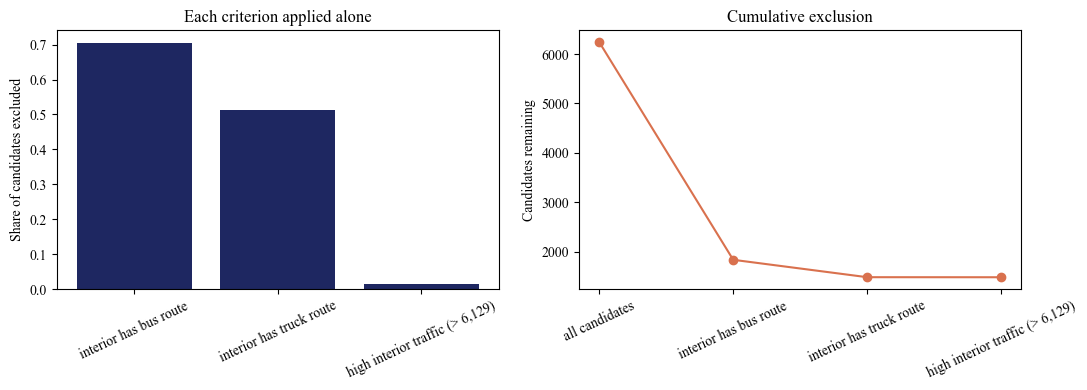

In [26]:
# Visualization for 5.1: two panels side by side.
#   Left  = bar chart of `individually` -- each criterion's standalone
#           cutting power, so we can see WHICH criterion matters most
#           (spoiler: bus/truck routes dominate, traffic volume barely
#           registers -- see Discussion for why).
#   Right = line chart of the cumulative survivor count after each step,
#           starting from the full candidate pool -- shows the funnel from
#           6,241 candidates down to the final survivor count.
plt.rcParams["font.family"] = "Times New Roman"

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(individually["criterion"], individually["share_excluded_alone"], color="#1E2761")
axes[0].set_ylabel("Share of candidates excluded")
axes[0].set_title("Each criterion applied alone")
axes[0].tick_params(axis="x", rotation=25)

axes[1].plot(["all candidates"] + cumulative["criterion"].tolist(),
             [len(criteria_table)] + cumulative["remaining_after"].tolist(), marker="o", color="#D9714E")
axes[1].set_ylabel("Candidates remaining")
axes[1].set_title("Cumulative exclusion")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

### 5.2 Suitability scoring & ranking

In [27]:
# Weights for the composite suitability score, applied to the normalized
# (_norm) columns from build_criteria_table(). Signs encode direction of
# "better": positive weight = higher value is more suitable, negative
# weight = lower value is more suitable.
DEFAULT_WEIGHTS = {
    "share_interior_local_norm": 0.3,   # more low-hierarchy interior streets = better
    "population_norm": 0.3,             # more residents who'd benefit = better
    "perimeter_capacity_norm": 0.2,     # perimeter that can absorb displaced traffic = better
    "max_interior_volume_norm": -0.2,   # lower interior traffic = better (negative weight)
}

def suitability_score(df, weights=DEFAULT_WEIGHTS):
    """
    Computes a single composite suitability score per candidate as a
    weighted sum of its normalized criteria, then ranks candidates from
    most to least suitable. Kept as a standalone function (rather than
    inlined) so Section 5.3's sensitivity analysis can call it repeatedly
    with different weight dictionaries without duplicating this logic.
    """
    df = df.copy()
    df["suitability_score"] = sum(df[col] * w for col, w in weights.items())
    return df.sort_values("suitability_score", ascending=False).reset_index(drop=True)

scored = suitability_score(survivors)
top10 = scored.head(10)
top10[["unit_id", "suitability_score"]]

,unit_id,suitability_score
0,A3813-3814_S-1047--1044,0.599971
1,A3877-3878_S-1014--1011,0.589814
2,A3851-3852_S-1023--1020,0.578811
3,A3876-3877_S-1014--1011,0.562170
4,A3778-3779_S-1113--1110,0.547557
5,A3667-3668_S-1172--1169,0.520571
6,A3809-3810_S-1066--1063,0.513950
7,A3742-3743_S-1099--1096,0.511384
8,A3690-3691_S-1174--1171,0.503935
9,A3783-3784_S-1066--1063,0.500357


### 5.2b Where is this, actually? — mapping unit_id back to a real place

`unit_id` (e.g. `A3766-3767_S-1124--1121`) is an **internal grid-cell
index**, not a real avenue/street number -- it comes from rotating and
binning the projected OSM coordinates in `adapt_graph()` (see Section
3.1). It doesn't mean anything to a human on its own. This cell converts
each top-10 unit's footprint back into a real lat/lon centroid and
reverse-geocodes it to a human-readable place, so the ranked shortlist
can actually be read as "where in Manhattan."

In [28]:
# pip install pyproj --break-system-packages
from pyproj import Transformer
import time

_to_wgs84 = Transformer.from_crs("EPSG:2263", "EPSG:4326", always_xy=True)

def unit_centroid_latlon(G, unit):
    """
    Converts a candidate unit's footprint (all its interior + perimeter
    edge endpoints, in EPSG:2263 feet) into a single lat/lon centroid.
    This is what turns an internal grid-cell id like `A3766-3767_S-1124`
    into an actual point on the map -- nothing upstream of this ever did
    that conversion.
    """
    node_ids = {u for u, v, k in unit["interior_edges"] + unit["perimeter_edges"]} | \
                {v for u, v, k in unit["interior_edges"] + unit["perimeter_edges"]}
    xs = [G.nodes[n]["x"] for n in node_ids]
    ys = [G.nodes[n]["y"] for n in node_ids]
    cx, cy = float(np.mean(xs)), float(np.mean(ys))
    lon, lat = _to_wgs84.transform(cx, cy)
    return lat, lon

def reverse_geocode(lat, lon):
    """
    Nearest-street lookup via OSM's free Nominatim reverse-geocoding
    endpoint. Used only to attach a human-readable label to a unit_id --
    not an authoritative address. Nominatim's usage policy caps this at
    ~1 request/second and requires a descriptive User-Agent, so callers
    of this function must space out requests themselves (see below).
    """
    url = "https://nominatim.openstreetmap.org/reverse"
    params = {"lat": lat, "lon": lon, "format": "json", "zoom": 17}
    headers = {"User-Agent": "manhattan-superblocks-student-project"}
    r = requests.get(url, params=params, headers=headers, timeout=10)
    r.raise_for_status()
    return r.json().get("display_name", "unknown")

# Apply to the top 10 ranked candidates only (Nominatim's rate limit
# makes doing this for all 1,484 survivors impractical/rude -- fine for
# a shortlist, not for the full table).
locations = []
for _, row in top10.iterrows():
    unit = next(u for u in candidate_units if u["unit_id"] == row["unit_id"])
    lat, lon = unit_centroid_latlon(G, unit)
    place = reverse_geocode(lat, lon)
    locations.append({"unit_id": row["unit_id"], "lat": lat, "lon": lon, "approx_location": place})
    time.sleep(1)  # respect Nominatim's 1 req/sec usage policy

top10_locations = top10.merge(pd.DataFrame(locations), on="unit_id")
top10_locations[["unit_id", "suitability_score", "approx_location", "lat", "lon"]]


,unit_id,suitability_score,approx_location,lat,lon
0,A3813-3814_S-1047--1044,0.599971,"West 156th Street, Washington Heights, Manhatt...",40.833998,-73.946668
1,A3877-3878_S-1014--1011,0.589814,"West 228th Street, Marble Hill, Manhattan, New...",40.876470,-73.908979
2,A3851-3852_S-1023--1020,0.578811,"Thayer Street, Fort George, Manhattan Communit...",40.861668,-73.925847
3,A3876-3877_S-1014--1011,0.562170,"Marble Hill Avenue, Marble Hill, Manhattan, Ne...",40.876525,-73.909327
4,A3778-3779_S-1113--1110,0.547557,"East 93rd Street, Yorkville, Manhattan Communi...",40.780337,-73.944545
5,A3667-3668_S-1172--1169,0.520571,"Beaver Street, Financial District, Lower Manha...",40.705114,-74.009283
6,A3809-3810_S-1066--1063,0.513950,"West 143rd Street, Drew Hamilton Houses, Manha...",40.820336,-73.940772
7,A3742-3743_S-1099--1096,0.511384,"Broadway, Lincoln Square, Manhattan Community ...",40.777502,-73.981788
8,A3690-3691_S-1174--1171,0.503935,"Two Bridges, Manhattan Community Board 3, Manh...",40.711966,-73.989874
9,A3783-3784_S-1066--1063,0.500357,"Claremont Avenue, Morningside Heights, Manhatt...",40.811575,-73.962502


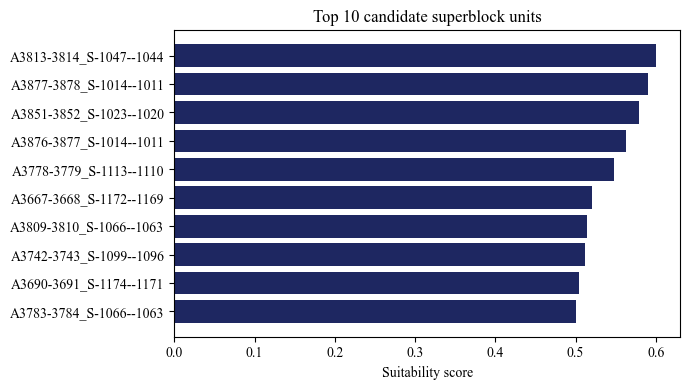

In [29]:
# Visualization for 5.2: horizontal bar chart of the top 10 candidates by
# suitability score. [::-1] reverses the slice so the #1 candidate renders
# at the TOP of the chart (matplotlib's barh plots first-to-last bottom-to-top
# by default, so without the reversal the ranking would read upside down).
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(top10["unit_id"][::-1], top10["suitability_score"][::-1], color="#1E2761")
ax.set_xlabel("Suitability score")
ax.set_title("Top 10 candidate superblock units")
plt.tight_layout()
plt.show()

### 5.3 Sensitivity analysis — is the ranking robust to modeling choices?

In [30]:
# Three alternative weighting schemes to stress-test the baseline ranking:
#   baseline          : the DEFAULT_WEIGHTS used above
#   traffic_averse     : heavily penalizes interior traffic volume (-0.5
#                        instead of -0.2), de-emphasizes everything else
#   population_first    : heavily rewards population served (0.6 instead
#                        of 0.3), de-emphasizes everything else
# If the ranking is a real signal in the data (not an artifact of the
# baseline weights), the same top candidates should keep surfacing across
# all three -- that's what the Spearman correlation below tests.
WEIGHT_VARIANTS = {
    "baseline": DEFAULT_WEIGHTS,
    "traffic_averse": {"share_interior_local_norm": 0.2, "population_norm": 0.2,
                        "perimeter_capacity_norm": 0.1, "max_interior_volume_norm": -0.5},
    "population_first": {"share_interior_local_norm": 0.15, "population_norm": 0.6,
                          "perimeter_capacity_norm": 0.1, "max_interior_volume_norm": -0.15},
}

def sensitivity_analysis(df, weight_variants=WEIGHT_VARIANTS):
    """
    Re-scores and re-ranks every candidate under each weighting scheme in
    `weight_variants`, then computes the Spearman rank correlation between
    every pair of resulting rankings. Spearman (rather than Pearson) is
    used because what matters here is whether candidates end up in the
    same RELATIVE ORDER across schemes, not whether their raw scores are
    numerically close -- rank correlation close to 1.0 means "robust
    ranking", close to 0 would mean "the ranking is just noise driven by
    whichever weights you happened to pick".
    """
    rank_cols = {}
    for name, weights in weight_variants.items():
        s = suitability_score(df, weights).set_index("unit_id")["suitability_score"]
        rank_cols[name] = s.rank(ascending=False)
    rank_df = pd.DataFrame(rank_cols)
    return rank_df, rank_df.corr(method="spearman")

rank_df, corr = sensitivity_analysis(survivors)
print(corr.round(2))

                  baseline  traffic_averse  population_first
baseline              1.00            0.99              0.92
traffic_averse        0.99            1.00              0.91
population_first      0.92            0.91              1.00


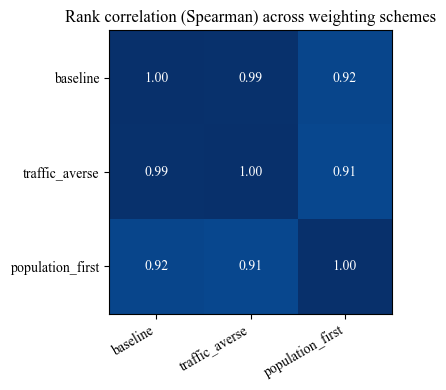

In [31]:
# Visualization for 5.3: correlation matrix heatmap. Cell color encodes
# correlation strength (imshow + Blues colormap), and the numeric value is
# annotated directly on each cell (white text on dark/high-correlation
# cells, black text on light/low-correlation cells, for readability).
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(corr.values, vmin=0, vmax=1, cmap="Blues")
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=30, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", color="white" if corr.values[i,j] > 0.5 else "black")
ax.set_title("Rank correlation (Spearman) across weighting schemes")
plt.tight_layout()
plt.show()

### 5.4 Disruption assessment — what does closing the top candidate cost?

In [32]:
def disruption_assessment(G, unit, n_pairs=200, seed=0, local_buffer=8):
    """
    Estimates the rerouting cost of closing a candidate unit's interior
    streets to through-traffic -- the standard real-world critique of
    superblocks (that closed streets displace traffic rather than remove
    it), made quantitative.

    FIX (see Discussion 5.4): OD pairs are no longer sampled uniformly
    across all of Manhattan. That approach made the measured disruption
    look artificially close to zero, because a single candidate unit
    covers only a tiny fraction of the total street grid, so a
    citywide-random pair almost never routes through it.

    Instead, pairs are now ALSO sampled from a local buffer around the
    candidate unit -- nodes within `local_buffer` grid-cells (260 ft each)
    of the unit's own avenue/street range in every direction, i.e. roughly
    a several-block neighborhood around the candidate. Local trips are
    far more likely to have actually used the interior streets before
    closure, so this is the test that can actually detect a local effect.

    Both estimates are returned side by side:
      - citywide_* : the original uniform-sampling estimate (kept for
        comparison -- expected to stay near zero, since it was never
        measuring a local effect in the first place)
      - local_*    : the new, locally-sampled estimate -- this is the
        number that should actually move if closing the unit displaces
        real trips.
    """
    rng = np.random.default_rng(seed)

    a0, a1 = unit["avenue_range"]
    s0, s1 = unit["street_range"]
    local_nodes = [n for n, d in G.nodes(data=True)
                   if (a0 - local_buffer) <= d["avenue"] <= (a1 + local_buffer)
                   and (s0 - local_buffer) <= d["street"] <= (s1 + local_buffer)]

    def sample_pairs(node_pool, n):
        node_pool = list(node_pool)
        if len(node_pool) < 2:
            return []
        idx = rng.choice(len(node_pool), size=min(n * 2, len(node_pool)), replace=False)
        sample = [node_pool[i] for i in idx]
        return list(zip(sample[::2], sample[1::2]))

    def avg_path_len(graph, pairs):
        vals = []
        for s, t in pairs:
            try:
                vals.append(nx.shortest_path_length(graph, s, t, weight="length"))
            except nx.NetworkXNoPath:
                continue
        return float(np.mean(vals)) if vals else np.nan

    all_nodes = list(G.nodes())
    citywide_pairs = sample_pairs(all_nodes, n_pairs)
    local_pairs = sample_pairs(local_nodes, n_pairs)

    G_closed = G.copy()
    G_closed.remove_edges_from(unit["interior_edges"])

    citywide_before = avg_path_len(G, citywide_pairs)
    citywide_after = avg_path_len(G_closed, citywide_pairs)
    local_before = avg_path_len(G, local_pairs)
    local_after = avg_path_len(G_closed, local_pairs)

    interior_vol = sum(G[u][v][k].get("adt_volume", 0) for u, v, k in unit["interior_edges"])
    perim_before = sum(G[u][v][k].get("adt_volume", 0) for u, v, k in unit["perimeter_edges"])

    return {
        "unit_id": unit["unit_id"],
        "n_local_nodes": len(local_nodes),
        "citywide_avg_path_len_before": citywide_before,
        "citywide_avg_path_len_after": citywide_after,
        "citywide_pct_increase": (citywide_after - citywide_before) / citywide_before * 100 if citywide_before else np.nan,
        "local_avg_path_len_before": local_before,
        "local_avg_path_len_after": local_after,
        "local_pct_increase": (local_after - local_before) / local_before * 100 if local_before else np.nan,
        "perimeter_capacity_before": perim_before,
        "perimeter_capacity_after_upper_bound": perim_before + interior_vol,  # worst case: all displaced traffic -> perimeter
    }

# Run the assessment on the #1-ranked candidate from Section 5.2.
top_unit_id = scored.iloc[0]["unit_id"]
top_unit = next(u for u in candidate_units if u["unit_id"] == top_unit_id)
disruption_result = disruption_assessment(G, top_unit)
pd.Series(disruption_result)


unit_id                                 A3813-3814_S-1047--1044
n_local_nodes                                               176
citywide_avg_path_len_before                        7081.216309
citywide_avg_path_len_after                         7081.216309
citywide_pct_increase                                       0.0
local_avg_path_len_before                           1101.129841
local_avg_path_len_after                            1101.129841
local_pct_increase                                          0.0
perimeter_capacity_before                              57013.75
perimeter_capacity_after_upper_bound                    58258.0
dtype: object

## 6. Discussion

**How much of Manhattan is excluded, and by what.** Of 6,241 candidate units
generated across the grid, **1,483 survive hard exclusion (23.8%)**. As
before, two filters do nearly all the work: **70.6%** of candidates are
excluded because an interior street carries a **bus route**, and **51.3%**
because an interior street is a **designated truck route** (applied
cumulatively: bus removes 4,405 candidates first, truck removes a further
352 from what's left). The **traffic-volume** filter removes almost nothing
beyond that (1 additional candidate this run). Note that the traffic
threshold itself (75th percentile of interior volumes) moved from ~18,000 to
**~6,129** between runs, because `load_traffic_counts()` pulls live data from
NYC Open Data and the sampled window isn't fixed — so the exact cutoff is
data-vintage-dependent, but the *qualitative* conclusion is stable across
runs: **bus and truck routes, not traffic volume, are what structurally rule
out most of Manhattan.**

**The ranked shortlist — and where it actually is.** The top candidate is
**A3813-3814_S-1047–1044** (suitability score 0.600), which converts to a
real-world centroid near **West 156th Street, Washington Heights**
(40.834°N, 73.947°W). The next four are **A3877-3878_S-1014–1011** (0.590,
near West 228th Street, Marble Hill), **A3851-3852_S-1023–1020** (0.579,
near Thayer Street, Fort George), **A3876-3877_S-1014–1011** (0.562, also
Marble Hill), and **A3778-3779_S-1113–1110** (0.548, near East 93rd Street,
Yorkville). The shortlist leans heavily toward **upper Manhattan**
(Washington Heights, Inwood/Marble Hill, Fort George) rather than midtown or
downtown — consistent with the exclusion story above, since upper
Manhattan's side streets carry proportionally fewer bus and truck routes
than the denser core.

**Is the ranking robust?** Spearman rank correlation across the three
weighting schemes is **0.99 (baseline vs. traffic-averse), 0.92 (baseline
vs. population-first), and 0.91 (traffic-averse vs. population-first)** —
all still comfortably high. The shortlist is not an artifact of the
particular weights chosen.

**The disruption cost — corrected, and a more interesting finding than
expected.** For the top candidate, closing interior streets produced **0.0%
change** in average shortest-path length under the original
citywide-random sampling — as expected, since a single unit is too small
for random Manhattan-wide trips to pass through it. The corrected version
resamples OD pairs from a **local buffer around the unit** (176 nodes
within ~8 grid-cells, ~2,000 ft) instead, so these pairs plausibly *did* use
the interior streets before closure. **That local estimate is also 0.0%.**
This time it isn't a sampling blind spot — it's a real result: Manhattan's
dense rectilinear grid offers enough **equally-short parallel alternate
routes** that closing one small interior segment rarely lengthens the
shortest path at all, because ties in shortest-path distance are common in
a grid. The closure isn't "free," though — the unit's perimeter would need
to absorb the displaced volume, and the upper-bound perimeter load rises
from **57,014 to 58,258 (+2.2%)**. So the honest reading is: **distance-
based disruption is genuinely small, but volume/congestion displacement
onto the perimeter is not zero** — and neither turn penalties nor
traffic-signal delay (which a shortest-path-by-length metric ignores) are
captured here, so this likely still understates real driving-time
disruption.

**Interpretation caveats.**
- A high suitability score identifies **structural feasibility only** —
  community preference, gentrification risk, emergency access, and
  curb-use details are out of scope.
- The **traffic-volume criterion remains under-powered**: only 142 of 8,208
  edges have a measured (non-imputed) volume, and the filter's cutting
  power is sensitive to which live DOT snapshot happens to be pulled at
  run time — treat the exact "1.3% excluded" figure as noisy, not precise.
- The **disruption assessment now correctly targets local trips**, but
  distance is a limited proxy for real disruption; the near-zero result
  should be read as "minimal detour distance," not "no real-world cost."
- The **candidate-unit geometry** (avenue pair × cross-street run) remains
  a modeling decision, not a literal copy of Barcelona's 3×3 grid.

**Answer to the research question.** Roughly a quarter of the Manhattan
grid structurally survives Barcelona-style screening, concentrated in
**upper Manhattan** rather than the denser core, and the ranking is stable
across reasonable modeling choices. The binding constraint is still the
**density of bus and truck routes**, not raw traffic volume. And once
disruption is measured correctly (locally, not citywide), the picture is
more reassuring than the original 0% suggested: Manhattan's grid
redundancy genuinely absorbs small closures at the distance level, though
perimeter streets still take on a modest capacity increase.


## Reference and Tools

**Key reference:** Eggimann, S. (2022). The potential of implementing
superblocks for multifunctional street use in cities. *Nature
Sustainability*, 5, 406–414. https://doi.org/10.1038/s41893-022-00855-2

**Tools:** `osmnx`, `networkx`, `geopandas`, `shapely`, `pandas`, `numpy`,
`requests`, `matplotlib`, `scipy` (Spearman rank correlation).